In [1]:
import pandas as pd
df=pd.read_csv(r"df_final_demo.txt")


In [2]:
part1=pd.read_csv(r"df_final_web_data_pt_1.txt")


In [3]:
part2=pd.read_csv(r"df_final_web_data_pt_2.txt")


In [4]:
df_concated=pd.concat([part1,part2], ignore_index=True)


In [5]:
Variation=pd.read_csv(r"df_final_experiment_clients.txt")


In [6]:
merged = pd.merge(df, df_concated, on='client_id', how='inner')

In [7]:
full_df = pd.merge(merged, Variation, on='client_id', how='inner')


In [8]:
full_df.shape

(449831, 14)

In [9]:
full_df=full_df.drop_duplicates()

In [10]:
full_df = full_df[full_df["gendr"].isin(["M", "F"])]

In [11]:
full_df=full_df.dropna()

In [12]:
full_df.isna().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
visitor_id          0
visit_id            0
process_step        0
date_time           0
Variation           0
dtype: int64

In [13]:
primary_cilents=full_df.groupby('client_id').agg({'visit_id': 'count'}).sort_values(by='visit_id',ascending=False).head(10)
primary_cilents

,visit_id
client_id,
465007,72
9638063,71
4167815,61
5165430,60
2261960,59
7597144,58
711827,54
1595223,53
5601303,52


In [14]:
test_table=full_df[full_df['Variation'].str.lower() == 'test']
test_table

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,visitor_id,visit_id,process_step,date_time,Variation
22,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,391202328_71710993352,71954691_44810191073_495385,start,2017-04-06 19:03:46,Test
36,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,56607555_75044897582,247503697_11679931698_453228,confirm,2017-04-06 10:48:22,Test
37,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,56607555_75044897582,247503697_11679931698_453228,step_3,2017-04-06 10:45:09,Test
38,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,56607555_75044897582,247503697_11679931698_453228,step_2,2017-04-06 10:41:56,Test
39,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,56607555_75044897582,247503697_11679931698_453228,step_1,2017-04-06 10:39:23,Test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321304,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,317123960_46820919455,769876461_30381166055_830233,step_2,2017-03-30 23:59:15,Test
321305,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,317123960_46820919455,769876461_30381166055_830233,step_1,2017-03-30 23:58:51,Test
321306,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,317123960_46820919455,769876461_30381166055_830233,start,2017-03-30 23:58:40,Test
321307,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,317123960_46820919455,769876461_30381166055_830233,start,2017-03-30 23:55:11,Test


In [15]:
control_table = full_df[full_df['Variation'].str.lower() == 'control']
control_table

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,visitor_id,visit_id,process_step,date_time,Variation
23,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,432077852_35036160885,942996157_39527225999_589383,start,2017-06-14 14:22:31,Control
41,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,667009768_32934260678,545534470_5635716155_93472,confirm,2017-03-29 11:57:25,Control
42,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,667009768_32934260678,545534470_5635716155_93472,step_3,2017-03-29 11:55:31,Control
43,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,667009768_32934260678,545534470_5635716155_93472,step_2,2017-03-29 11:55:27,Control
44,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,667009768_32934260678,545534470_5635716155_93472,step_3,2017-03-29 11:54:55,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321283,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,663474827_38847225720,923772865_74694577233_449836,confirm,2017-04-12 19:06:55,Control
321284,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,663474827_38847225720,923772865_74694577233_449836,step_3,2017-04-12 19:05:14,Control
321285,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,663474827_38847225720,923772865_74694577233_449836,step_2,2017-04-12 19:04:29,Control
321286,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,663474827_38847225720,923772865_74694577233_449836,step_1,2017-04-12 19:04:07,Control


In [16]:
test_table.duplicated().sum()

np.int64(0)

In [ ]:

start_users = test_table[test_table['process_step'] == 'start']['client_id'].nunique()

completed_users = test_table[test_table['process_step'] == 'confirm']['client_id'].nunique
completion_rate = round((completed_users / start_users) * 100, 2)
print(f"Completion rate: {completion_rate}%")

Completion rate: 69.74%


In [115]:
# Step 1: Identify completed clients
completed_clients = test_table[test_table["process_step"] == "confirm"]["client_id"].unique()

# Step 2: Flag each row as completed or not
test_table['completed_flag'] = test_table['client_id'].isin(completed_clients).map({True: 'yes', False: 'no'})


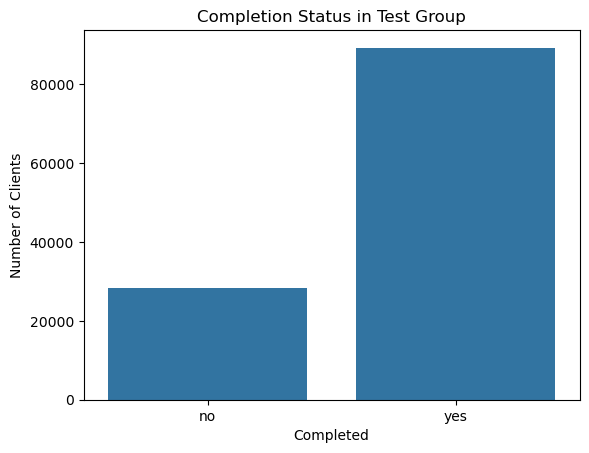

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot
sns.countplot(x='completed_flag', data=test_table)
plt.title("Completion Status in Test Group")
plt.xlabel("Completed")
plt.ylabel("Number of Clients")
plt.show()



In [114]:
#control_table
# Total users who started
start_users = control_table[control_table['process_step'] == 'start']['client_id'].nunique()

# Total users who completed (reached 'confirm')
completed_users = control_table[control_table['process_step'] == 'confirm']['client_id'].nunique()

# Completion rate
completion_rate = round((completed_users / start_users) * 100, 2)
print(f"Completion rate: {completion_rate}%")

Completion rate: 65.36%


In [117]:
# Step 1: Identify completed clients
completed_clients = control_table[control_table["process_step"] == "confirm"]["client_id"].unique()

# Step 2: Flag each row as completed or not
control_table['completed_flag'] = control_table['client_id'].isin(completed_clients).map({True: 'yes', False: 'no'})


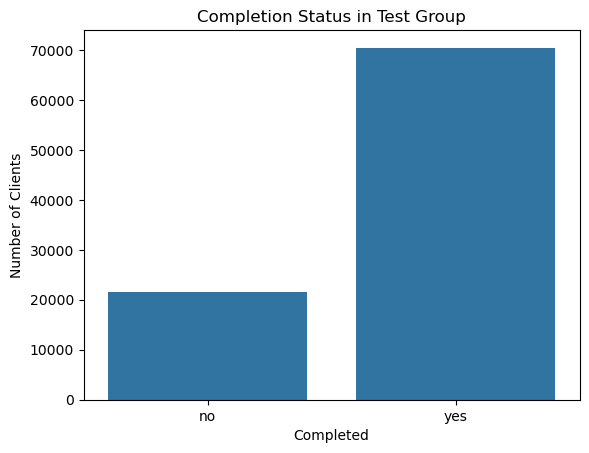

In [118]:
sns.countplot(x='completed_flag', data=control_table)
plt.title("Completion Status in Test Group")
plt.xlabel("Completed")
plt.ylabel("Number of Clients")
plt.show()

In [119]:
crosstab=pd.crosstab(test_table['process_step'], test_table['completed_flag'])


In [120]:
#chi_square
from scipy.stats import chi2_contingency
_,chi2_contingency,_,_=chi2_contingency(crosstab)
chi2_contingency

np.float64(0.0)

In [121]:
#person correlation
test_table['step_code'] = test_table['process_step'].astype('category').cat.codes
test_table['step_code'].corr(test_table['client_id'])

np.float64(0.0017100371896456297)

In [30]:
#the process_step increaes the client_id increases

In [31]:
#H₀: Completion rate in test group ≤ control group
#H₁: Completion rate in test group > control group
#0.05

In [125]:
from statsmodels.stats.proportion import proportions_ztest


# Count completions
completed_t = (test_table['completed_flag'] == 'yes').sum()
completed_c = (control_table['completed_flag'] == 'yes').sum()

# Total observations
total_t = test_table['completed_flag'].count()
total_c = control_table['completed_flag'].count()

# Run one-sided z-test (Test > Control)
stat, pval = proportions_ztest([completed_t, completed_c], [total_t, total_c], alternative='larger')

print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")




Z-statistic: -2.9124
P-value: 0.9982


In [ ]:
#reject the null hypothesis and completion rate test group is more
#reject the null hypothesis and completion status for test group is more

In [152]:
# Step 1: Make a clean copy
test_table = test_table.copy()

# Step 2: Convert date_time in test_table, not merged
test_table['date_time'] = pd.to_datetime(test_table['date_time'], errors='coerce')

# Step 3: Sort and calculate time spent
sorted_test = test_table.sort_values(by=['visit_id', 'date_time'])

test_table['time_spent_minutes'] = (
    sorted_test.groupby('visit_id')['date_time']
    .diff()
    .abs()
    .dt.total_seconds() / 60
    
)

test_table['time_spent_minutes']
#diff() is difference between dates
#abs() convert -ve to +ve
#dt.total_seconds()/60 is to convert into minutes

22              NaN
36         3.216667
37         3.216667
38         2.550000
39         0.833333
            ...    
321304     0.400000
321305     0.183333
321306     3.483333
321307          NaN
321308    16.650000
Name: time_spent_minutes, Length: 117457, dtype: float64

In [153]:
mean = test_table['time_spent_minutes'].mean()
test_table['time_spent_minutes'].fillna(mean, inplace=True)
test_table['time_spent_minutes']=test_table['time_spent_minutes'].round(2)

In [154]:
Q1 = test_table['time_spent_minutes'].quantile(0.25)
Q3 = test_table['time_spent_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

test_table = test_table[(test_table['time_spent_minutes'] >= lower_bound) & (test_table['time_spent_minutes'] <= upper_bound)]

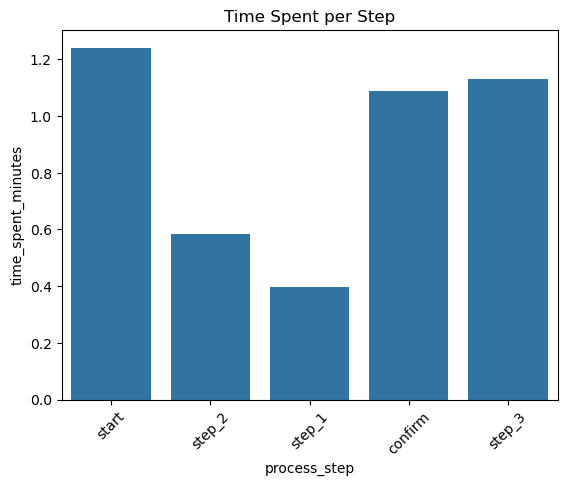

In [155]:
sns.barplot(x='process_step', y='time_spent_minutes', data=test_table,errorbar=None)
plt.title("Time Spent per Step")
plt.xticks(rotation=45)
plt.show()


In [156]:
test_table.groupby('process_step')['time_spent_minutes'].mean()
#. Average Time per Step

process_step
confirm    1.089646
start      1.241477
step_1     0.396656
step_2     0.584409
step_3     1.129200
Name: time_spent_minutes, dtype: float64

In [157]:

# Make a clean copy
control_table = control_table.copy()

# Step 2: Convert date_time in test_table, not merged
control_table['date_time'] = pd.to_datetime(control_table['date_time'], errors='coerce')

# Step 3: Sort and calculate time spent
sorted_control = control_table.sort_values(by=['visit_id', 'date_time','client_id'])

control_table['time_spent_minutes'] = (
    sorted_control.groupby('visit_id')['date_time']
    .diff()
    .abs()
    .dt.total_seconds() / 60
)

In [ ]:
control_table.groupby('visit_id')['time_spent_minutes'].sum()
# Total Time per Visit

In [ ]:
control_table.groupby('process_step')['time_spent_minutes'].mean()
#. Average Time per Step

In [ ]:
mean = control_table['time_spent_minutes'].mean()
control_table['time_spent_minutes'].fillna(mean, inplace=True)
control_table['time_spent_minutes']=control_table['time_spent_minutes'].round(2)

In [159]:
Q1 = control_table['time_spent_minutes'].quantile(0.25)
Q3 = control_table['time_spent_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
control_table= control_table[(control_table['time_spent_minutes'] >= lower_bound) & (control_table['time_spent_minutes'] <= upper_bound)]

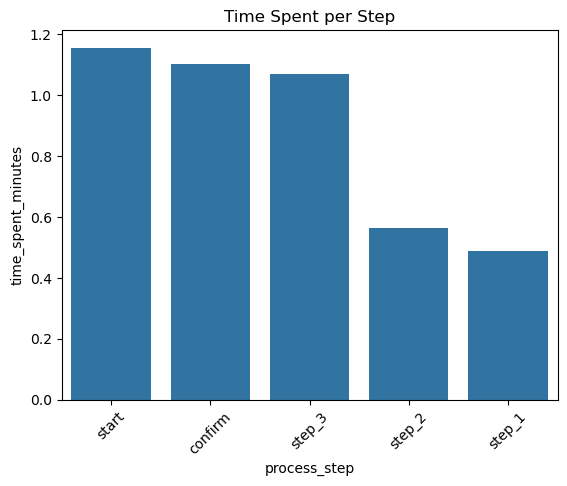

In [160]:
sns.barplot(x='process_step', y='time_spent_minutes', data=control_table,errorbar=None)
plt.title("Time Spent per Step")
plt.xticks(rotation=45)
plt.show()

In [161]:
c=pd.crosstab(test_table["process_step"],test_table["time_spent_minutes"])

In [162]:
#chi_square
from scipy.stats import chi2_contingency
_,chi2_contingency,_,_=chi2_contingency(c)
chi2_contingency

np.float64(0.0)

In [163]:
#cramers method
from scipy.stats.contingency  import association
association(c,method="cramer")

0.44584839062539927

In [46]:
#very weak association and also strength of association is weak between process step and time spent minutes.

In [164]:
#correlation pearson
#converting into numeric codes
test_table['step_code'] = test_table['process_step'].astype('category').cat.codes
test_table['step_code'].corr(test_table['time_spent_minutes'])


np.float64(-0.1780919729838034)

In [165]:
#spearman
test_table['step_code'].corr(test_table['time_spent_minutes'],method="spearman")

np.float64(-0.24750710291114827)

In [49]:
#higher step codes, tend to spend slightly less time per step.

In [50]:
# H₀: Mean time spent in test group <= mean time spent in control group

#H₁: Mean time spent in test group >= mean time spent in control group
#0.05

In [166]:
from scipy.stats import ttest_ind
#step-start
test_times = test_table[test_table["process_step"] == 'start']["time_spent_minutes"].dropna()
control_times = control_table[control_table["process_step"] == 'start']["time_spent_minutes"].dropna()

ttest_ind(test_times, control_times,alternative = "greater")


TtestResult(statistic=np.float64(22.250964538934785), pvalue=np.float64(1.5006447546555148e-109), df=np.float64(61190.0))

In [168]:
from scipy.stats import ttest_ind

steps = sorted_test['process_step'].dropna().unique()

for step in steps:
    test_times = test_table[test_table['process_step'] == step]['time_spent_minutes'].dropna()
    control_times = control_table[control_table['process_step'] == step]['time_spent_minutes'].dropna()
    stat, p_value = ttest_ind(test_times, control_times, alternative = "greater")
    print(f"Step: {step}")
    print(f"  p-value: {p_value}")


Step: start
  p-value: 1.5006447546555148e-109
Step: step_1
  p-value: 1.0
Step: step_2
  p-value: 0.00020559321022458395
Step: step_3
  p-value: 1.4275141447972377e-14
Step: confirm
  p-value: 0.930410966194606


In [ ]:
#rejected H0 and  test group spent more time


In [54]:
#Error Rate Calculation
step_order = {
    'start': 1,
    'step_1': 2,
    'step_2': 3,
    'step_3': 4,
    'confirm': 5
}

def error_rate(df, step_order):
    # Convert process steps to numeric order
    df = df.replace({'process_step': step_order})
    
    # Sort by client/session and time
    df = df.sort_values(['client_id', 'visit_id', 'date_time'])
    
    # Get previous step
    df['prev_step'] = df.groupby(['client_id', 'visit_id'])['process_step'].shift()
    
    # Check for backward movements (errors)
    df['backward_move'] = df['process_step'] < df['prev_step']
    
    # Calculate total errors and rate
    errors = df['backward_move'].sum()
    total_moves = df['process_step'].count()
    return errors / total_moves

# Calculate separately for each group
test_error = error_rate(test_table, step_order)
control_error = error_rate(control_table, step_order)

print(f"Test Error Rate: {test_error:.2%}")
print(f"Control Error Rate: {control_error:.2%}")


C:\Users\prodd\AppData\Local\Temp\ipykernel_24192\809893869.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'process_step': step_order})


Test Error Rate: 9.41%
Control Error Rate: 6.58%


C:\Users\prodd\AppData\Local\Temp\ipykernel_24192\809893869.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'process_step': step_order})


In [105]:
# Build per-client error rates and run a Two-Sample (Independent) T-Test on means
def individual_error_rate(df, step_order):
    df = df.replace({'process_step': step_order})
    df = df.sort_values(['client_id', 'visit_id', 'date_time'])
    df['prev_step'] = df.groupby(['client_id', 'visit_id'])['process_step'].shift()
    df['backward_move'] = df['process_step'] < df['prev_step']
    return df.groupby('client_id')['backward_move'].mean().reset_index(name='error_rate')

test_individual = individual_error_rate(test_table, step_order)
control_individual = individual_error_rate(control_table, step_order)

C:\Users\prodd\AppData\Local\Temp\ipykernel_24192\3425981324.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'process_step': step_order})
C:\Users\prodd\AppData\Local\Temp\ipykernel_24192\3425981324.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'process_step': step_order})


In [56]:
from scipy import stats as st

t_stat, p_val = st.ttest_ind(
    test_individual['error_rate'],
    control_individual['error_rate'],
    alternative='greater'  # because Test is expected to have higher error rate
)
p_val

np.float64(2.7640291152769356e-94)

In [57]:
# If p-value < 0.05, reject H₀ → The mean error rate of the Test and Control groups are the same, or the Test’s is lower.

# If p-value ≥ 0.05, fail to reject H₀ → Fail to reject H₀: The mean error rate of the Test group is higher than the Control group.